In [11]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
np.random.seed(42)
n = 500

y = np.random.uniform(0, 1, n) 

leaked_feature = y * 2 + np.random.normal(0, 0.01, n) 
noise_feature = np.random.normal(0, 1, n) 

df_mini = pd.DataFrame({"y": y, "leaked": leaked_feature, "noise": noise_feature})

print("Pearson:")
print(df_mini.corr()["y"])

print("\nSpearman:")
print(df_mini.corr(method="spearman")["y"])

Pearson:
y         1.000000
leaked    0.999859
noise     0.098189
Name: y, dtype: float64

Spearman:
y         1.000000
leaked    0.999764
noise     0.103967
Name: y, dtype: float64


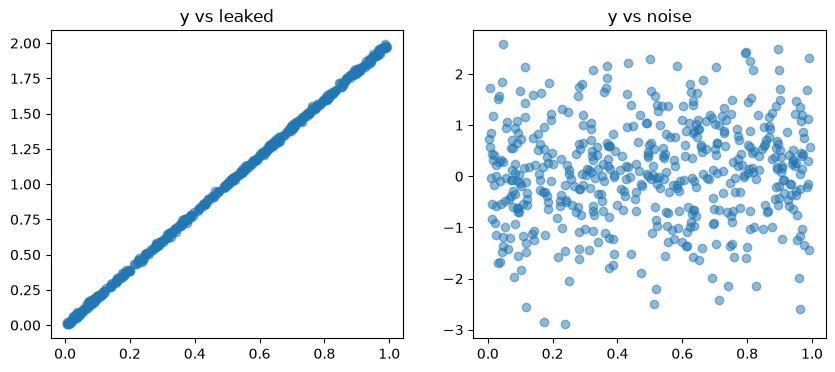

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(df_mini["y"], df_mini["leaked"], alpha=0.5)
axes[0].set_title("y vs leaked")
axes[1].scatter(df_mini["y"], df_mini["noise"], alpha=0.5)
axes[1].set_title("y vs noise")
plt.show()

In [4]:
import duckdb
import pandas as pd

duckdb.sql("CREATE VIEW duolingo_flagship AS SELECT * FROM read_csv_auto('../../data/duolingo_flagship_v4.csv')")
df = duckdb.sql("SELECT * FROM duolingo_flagship").df()

numeric_cols = ["lag_days", "history_seen", "history_correct", "history_accuracy", "lag_days_log"]
categorical_cols = ["pos", "ui_language", "learning_language"]

In [5]:
pearson_corr = df[numeric_cols + ["p_recall"]].corr()["p_recall"]

In [6]:
pearson_corr

lag_days           -0.023941
history_seen       -0.004746
history_correct     0.000467
history_accuracy    0.116493
lag_days_log       -0.042862
p_recall            1.000000
Name: p_recall, dtype: float64

In [7]:
spearmen_corr = df[numeric_cols + ["p_recall"]].corr(method="spearman")["p_recall"]

In [8]:
spearmen_corr

lag_days           -0.046316
history_seen        0.012299
history_correct     0.034448
history_accuracy    0.112871
lag_days_log       -0.046316
p_recall            1.000000
Name: p_recall, dtype: float64

In [9]:
for col in categorical_cols:
    result = df.groupby(col)["p_recall"].agg(["mean","std","count"]).sort_values("mean", ascending=False)
    print(f"\n{col}:")
    print(result)


pos:
                                   mean       std  count
pos                                                     
@cnj:depuis_que                1.000000  0.000000      2
@cnj:pendant_que               1.000000       NaN      1
@cnj:parce_que                 1.000000       NaN      1
@cnj:tandis_que                1.000000       NaN      1
@common_phrases:comment_ca_va  1.000000       NaN      1
@ij:buenos_dias                1.000000  0.000000      9
@ij:buenas_noches              1.000000  0.000000      7
@pr:plus_de                    1.000000       NaN      1
np                             1.000000       NaN      1
rel                            1.000000  0.000000     14
pprep                          1.000000  0.000000      2
@itg:que_est_ce_que            1.000000       NaN      1
apos                           0.981771  0.050389     16
ij                             0.960970  0.160907    158
gen                            0.950000  0.158114     10
@adv:por_favor           

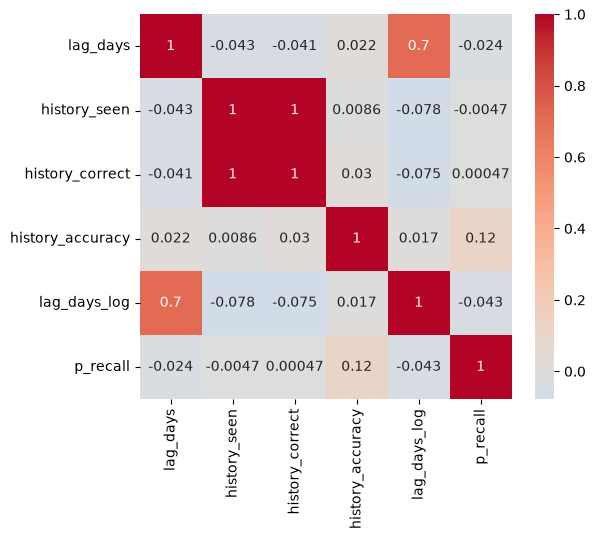

In [12]:
corr_matrix = df[numeric_cols + ["p_recall"]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, center=0, cmap="coolwarm", ax=ax)
fig.savefig("../../reports/figures/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Hypotheses

1. No numeric feature shows a strong linear or monotonic relationship with p_recall on its own (all |r| < 0.12). Predicting recall probably depends on combinations of features (or interactions a tree-based model could pick up), not any single one.

2. The leakage suspicion around history_accuracy didn't hold up , correlation is weak (0.12). A user's overall past accuracy is only loosely related to whether they recall this specific word right now. Safe to use as a feature.

4. learning_language="pt" has a noticeably lower mean (0.79) than the others (0.88-0.90), and the group is large enough (n=490) that this isn't just noise from a small sample. Worth a closer look later.

## Suspicious correlations

None of the numeric features are suspiciously high , nothing close to the leakage range we saw in the mini lab (0.99+). No red flags here.